
[INFO] Registros (Algoritmo x Derivado x Ano x Horizonte): 43200
[INFO] Algoritmos encontrados: ['AutoARIMA', 'AutoETS', 'Chronos', 'Ensemble', 'Moirai', 'NBEATS', 'PatchTST', 'RandomForest', 'SeasonalNaive', 'SimMTM', 'Time-MoE', 'Timer', 'TimesFM', 'UniTS', 'XGBRegressor', 'iTransformer']
[INFO] Modelos novos incluídos: ['SimMTM', 'UniTS']
[INFO] Horizontes: ['horizon_12', 'horizon_24', 'horizon_3', 'horizon_6']
[INFO] Derivados: ['Etanolhidratado', 'Gasolinac', 'Glp', 'Oleodiesel', 'Querosenedeaviacao']

[OK] Todas as 2700 instâncias têm os 16 algoritmos.


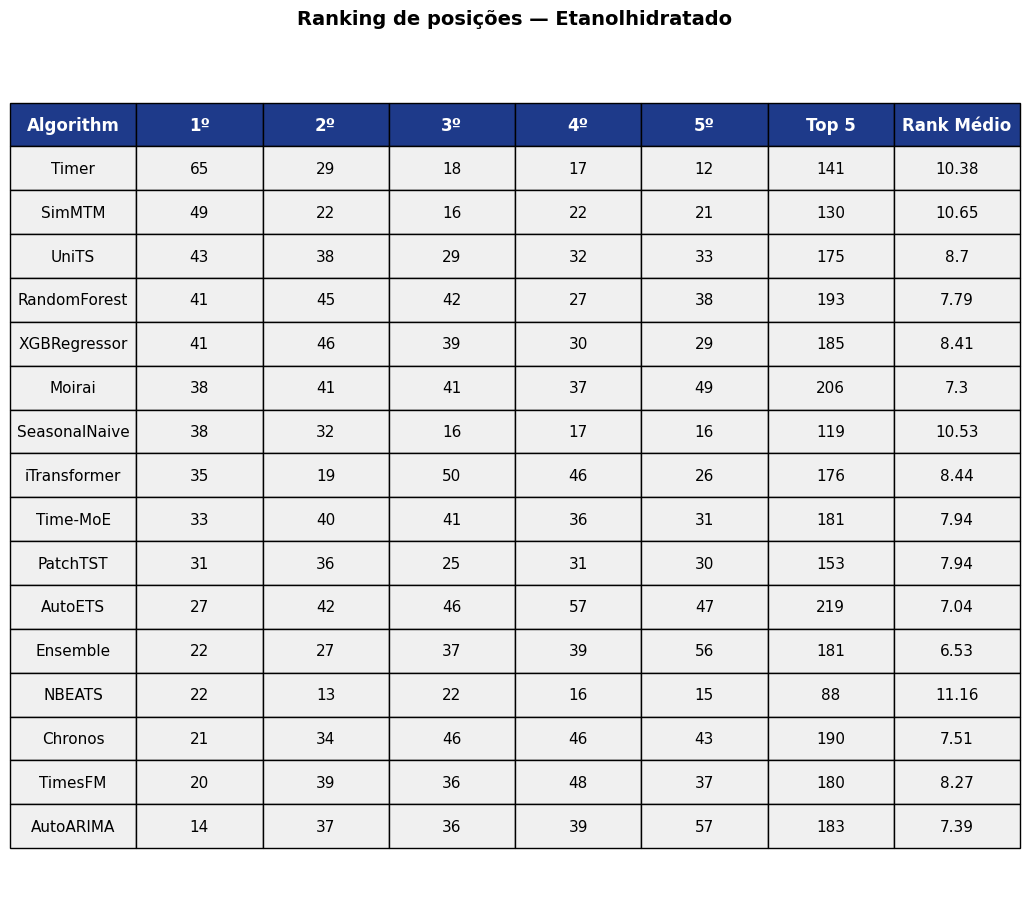

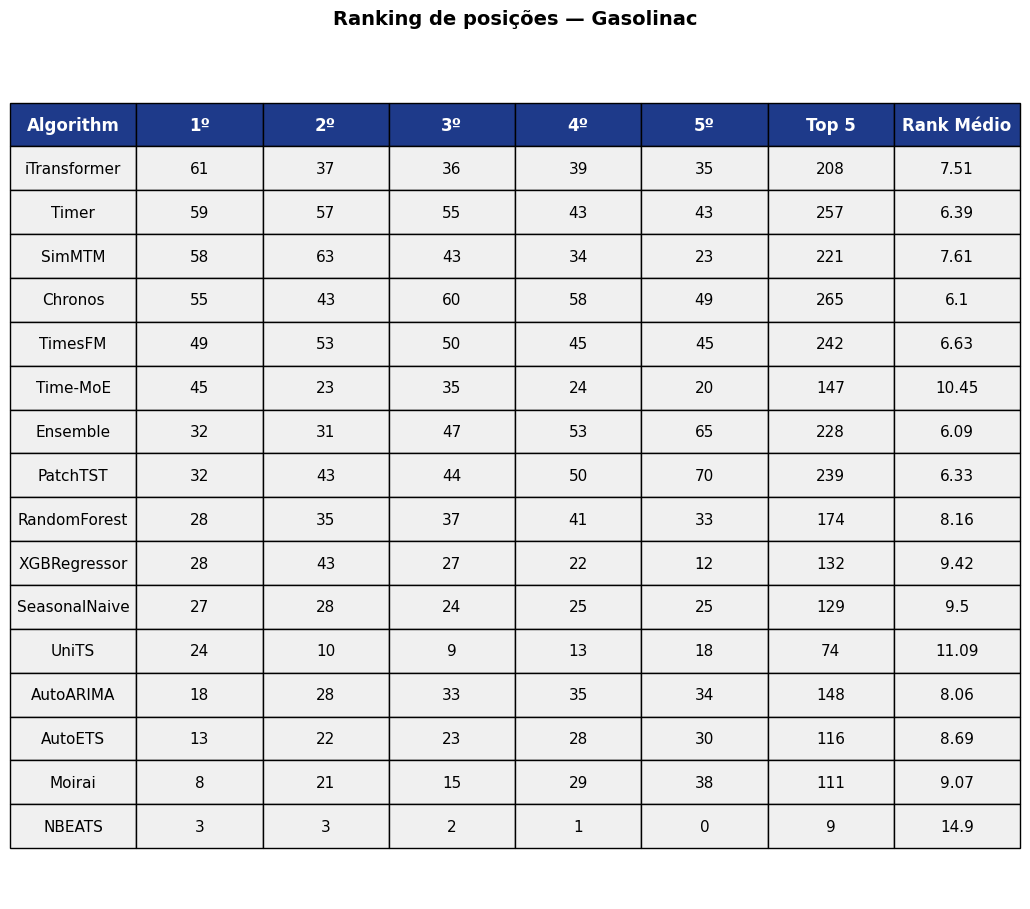

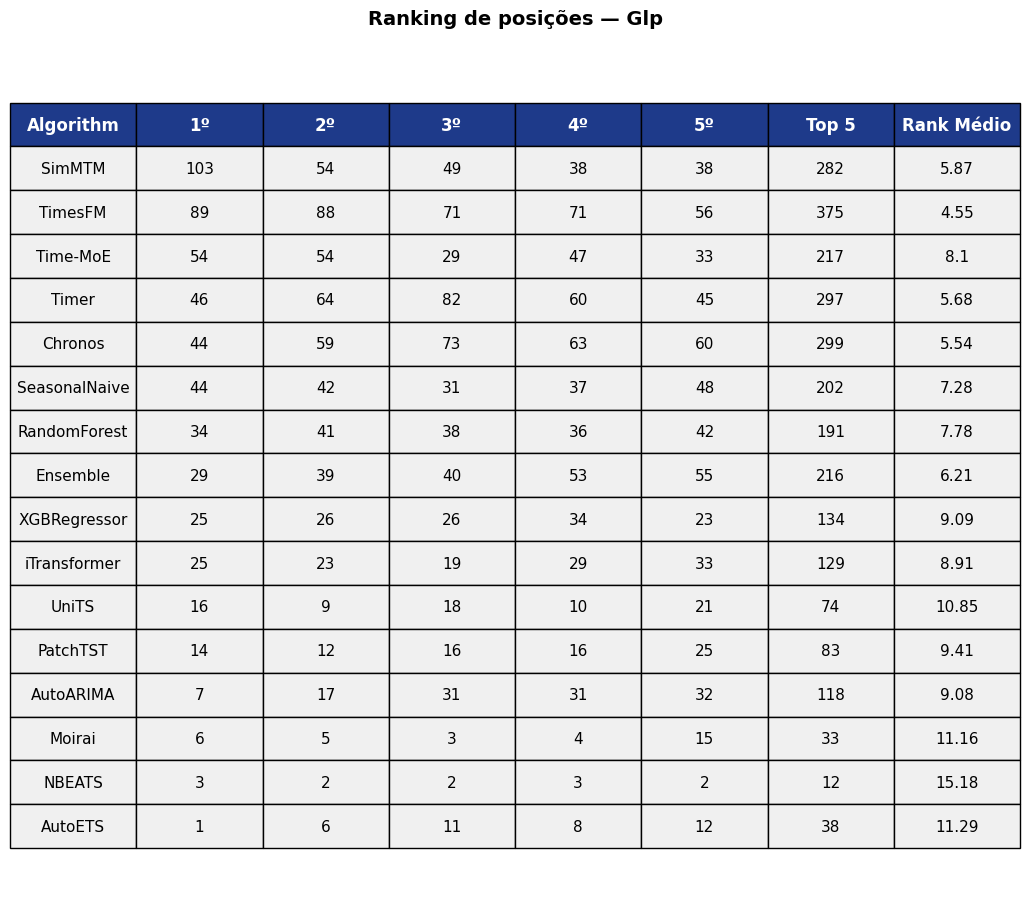

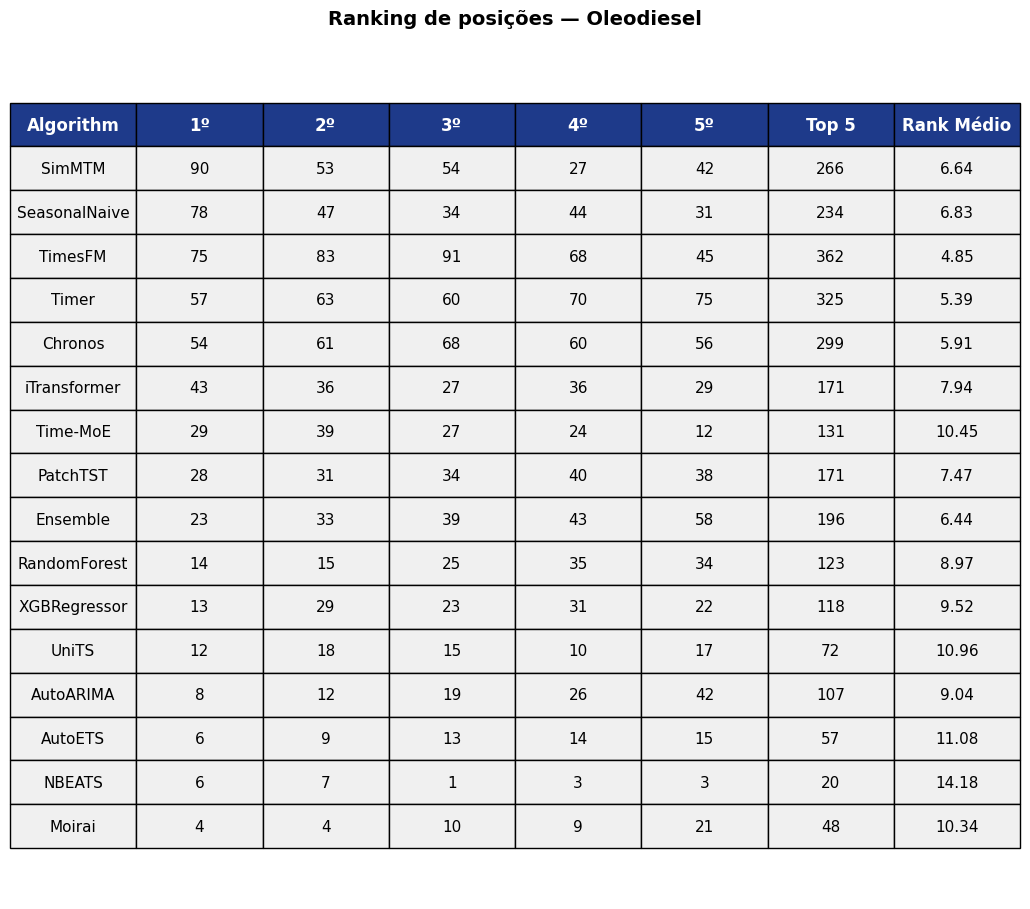

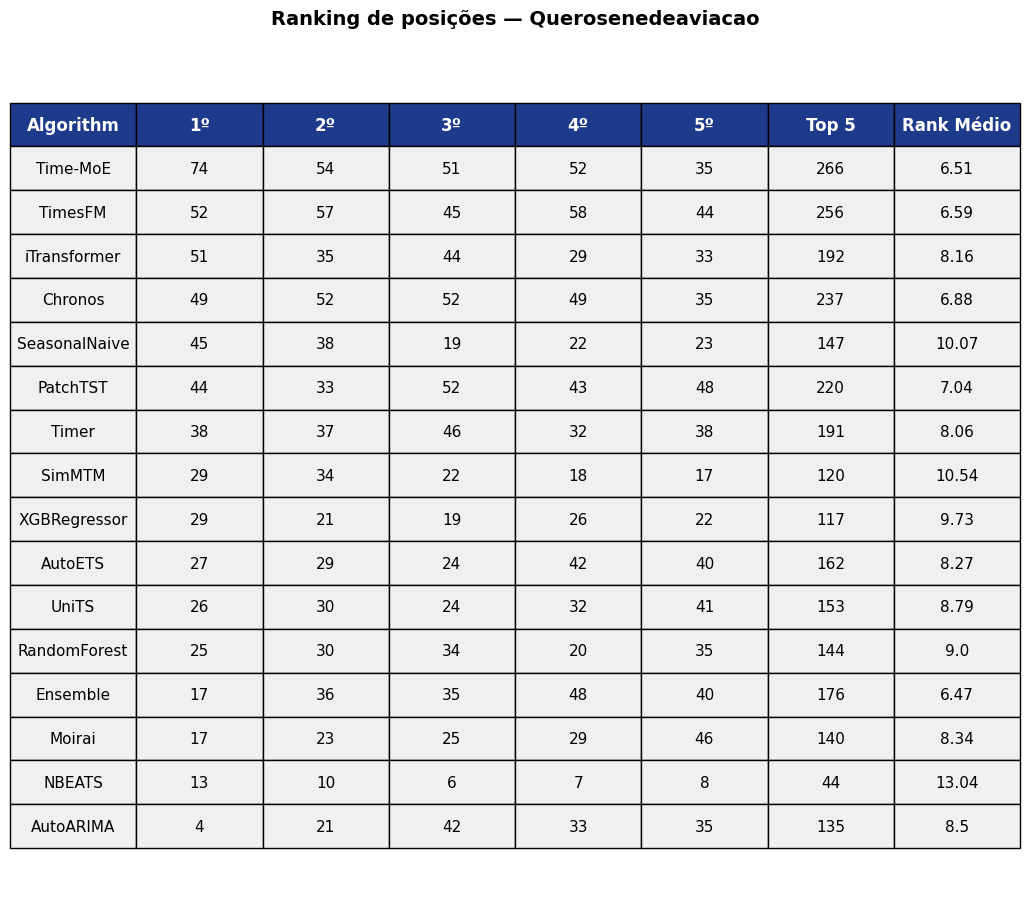

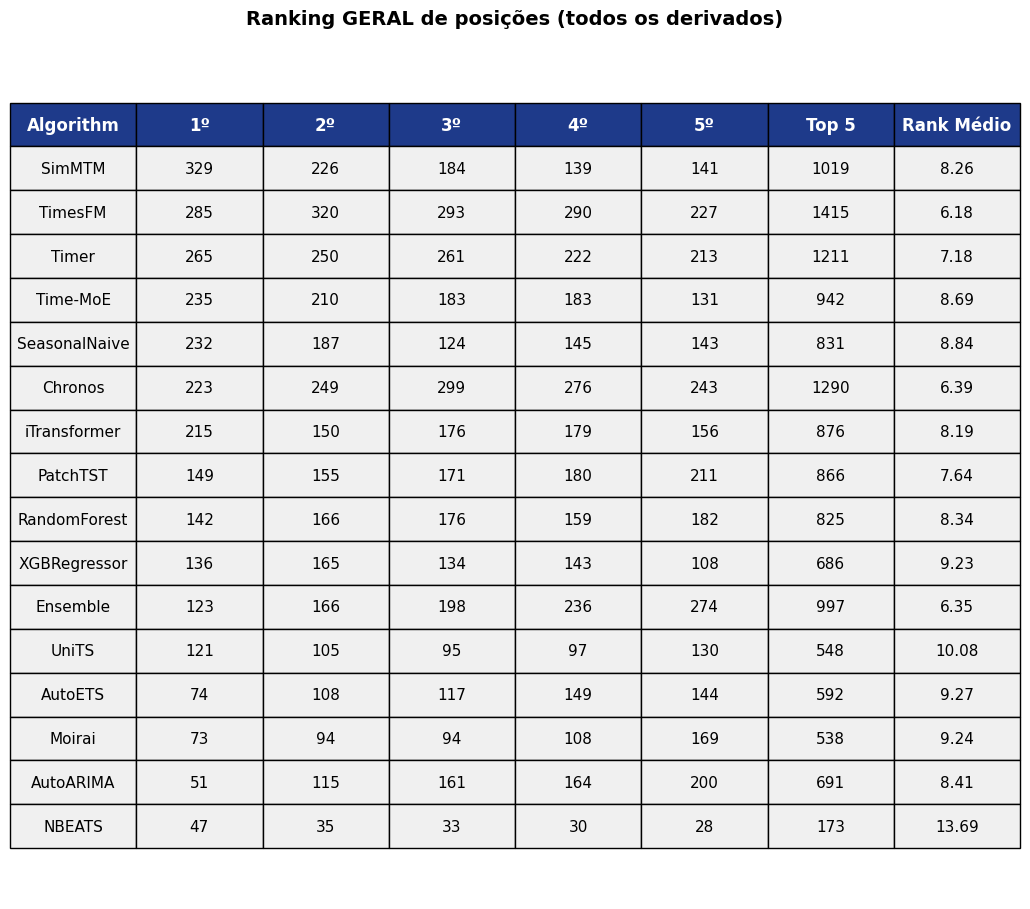


Rankings gerados com sucesso.


In [1]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# CONFIGURATION
# ==========================================================
BASE_RESULTS_PATH = "RESULTADOS_COMPLETOS_ANP/results_by_state_year"

# Resultados dos modelos adicionais (UniTS, SimMTM). Eles não dependem da
# configuração do MoE, então ficam em um diretório próprio com a mesma grade
# de arquivos results_<estado>_<ano>.csv por horizonte.
NEW_MODELS_PATH = "results_anp_novos_modelos/novos_models"
NEW_MODELS_LABEL = "novos_models"

TARGET_PRODUCTS = [
    "Etanolhidratado",
    "Gasolinac",
    "Glp",
    "Oleodiesel",
    "Querosenedeaviacao"
]

BEST_EXPERIMENTS = {
    "horizon_3":  "model_topk_2_norm_std_noise_True_ep_30_lr_0.001",
    "horizon_6":  "model_topk_2_norm_std_noise_True_ep_30_lr_0.001",
    "horizon_12": "model_topk_2_norm_std_noise_True_ep_100_lr_0.001",
    "horizon_24": "model_topk_2_norm_std_noise_True_ep_100_lr_0.001"
}

# Se quiser restringir a análise a um único horizonte, troque None por
# ex. "horizon_12". Deixando None, os rankings agregam todos os horizontes.
FILTER_HORIZON = None

# Menor erro = melhor colocação (1º lugar). Troque para False se a métrica
# usada for "quanto maior, melhor".
LOWER_IS_BETTER = True

# Onde salvar as tabelas de ranking em .csv (útil para depois montar as
# tabelas em LaTeX). Defina EXPORT_CSV = False para não salvar nada.
EXPORT_CSV = False
OUTPUT_DIR = "rankings_output"

# Mostra apenas as colocações de 1º até esse valor (as demais não aparecem
# nas tabelas/plots, mas ainda entram no cálculo do Rank Médio).
MAX_DISPLAY_RANK = 5

# Modelos a excluir da disputa (o ranking é recalculado sem eles, então os
# demais modelos "sobem" de posição normalmente).
IGNORE_MODELS = ["FM-MoE"]


# ==========================================================
# LEITURA DE UMA PASTA horizon_*
# ==========================================================
def read_long_rows(horizon_path, horizon, exp_name):
    """Formato longo: 1 linha por (Modelo, Derivado) de cada arquivo
    results_<estado>_<ano>.csv da pasta."""

    rows = []

    for file in sorted(os.listdir(horizon_path)):

        if not file.endswith(".csv"):
            continue

        # identificador da instância: results_<estado>_<ano>
        year = os.path.splitext(file)[0]
        file_path = os.path.join(horizon_path, file)

        df = pd.read_csv(file_path)

        metric_cols = [c for c in TARGET_PRODUCTS if c in df.columns]

        if len(metric_cols) == 0:
            print(f"[WARNING] No valid columns in {file_path}")
            continue

        for _, row in df.iterrows():
            for product in metric_cols:
                rows.append({
                    "Algorithm": row["Modelo"],
                    "Horizon": horizon,
                    "Year": year,
                    "Product": product,
                    "Error": row[product],
                    "Experiment": exp_name
                })

    return rows


# ==========================================================
# LOAD RESULTS (formato longo: 1 linha por Algoritmo x Horizonte x Ano x Derivado)
# ==========================================================
rows_long = []

for horizon, exp_name in BEST_EXPERIMENTS.items():

    if FILTER_HORIZON is not None and horizon != FILTER_HORIZON:
        continue

    # 1) modelos originais (melhor experimento daquele horizonte)
    exp_horizon_path = os.path.join(BASE_RESULTS_PATH, exp_name, horizon)

    if os.path.isdir(exp_horizon_path):
        rows_long.extend(read_long_rows(exp_horizon_path, horizon, exp_name))
    else:
        print(f"[WARNING] Experiment not found: {exp_horizon_path}")

    # 2) modelos novos (UniTS, SimMTM)
    new_horizon_path = os.path.join(NEW_MODELS_PATH, horizon)

    if os.path.isdir(new_horizon_path):
        rows_long.extend(read_long_rows(new_horizon_path, horizon, NEW_MODELS_LABEL))
    else:
        print(f"[WARNING] New models not found: {new_horizon_path}")

df_long = pd.DataFrame(rows_long)

if len(df_long) == 0:
    raise SystemExit("\n[ERROR] No data loaded. Check experiment paths.")

df_long = (
    df_long
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["Error"])
)

new_models = sorted(
    df_long.loc[df_long["Experiment"] == NEW_MODELS_LABEL, "Algorithm"].unique()
)

if IGNORE_MODELS:
    df_long = df_long[~df_long["Algorithm"].isin(IGNORE_MODELS)]

print(f"\n[INFO] Registros (Algoritmo x Derivado x Ano x Horizonte): {len(df_long)}")
print(f"[INFO] Algoritmos encontrados: {sorted(df_long['Algorithm'].unique())}")
print(f"[INFO] Modelos novos incluídos: {new_models}")
print(f"[INFO] Horizontes: {sorted(df_long['Horizon'].unique())}")
print(f"[INFO] Derivados: {sorted(df_long['Product'].unique())}")


# ==========================================================
# CHECAGEM DE INTEGRIDADE
# toda instância (Horizonte, Estado/Ano, Derivado) precisa ter o mesmo
# conjunto de algoritmos, senão a contagem de posições fica distorcida
# ==========================================================
n_algorithms = df_long["Algorithm"].nunique()

instance_sizes = (
    df_long
    .groupby(["Horizon", "Year", "Product"])["Algorithm"]
    .nunique()
)

if df_long.duplicated(subset=["Horizon", "Year", "Product", "Algorithm"]).any():
    raise ValueError(
        "Há linhas duplicadas por (Horizonte, Ano, Derivado, Algoritmo). "
        "Verifique se os resultados novos não foram carregados duas vezes."
    )

if (instance_sizes != n_algorithms).any():
    incompletas = instance_sizes[instance_sizes != n_algorithms]
    print(f"\n[WARNING] {len(incompletas)} instâncias não têm os "
          f"{n_algorithms} algoritmos. O ranking dessas instâncias fica "
          f"distorcido. Exemplos:")
    print(incompletas.head().to_string())
else:
    print(f"\n[OK] Todas as {len(instance_sizes)} instâncias têm os "
          f"{n_algorithms} algoritmos.")


# ==========================================================
# FUNÇÃO DE RANKING
# ==========================================================
def compute_rank_counts(df_group, group_keys):
    """
    Para cada combinação única de `group_keys` (uma "instância" de avaliação
    — ex: um Horizonte+Ano, ou um Horizonte+Ano+Derivado), ordena os modelos
    pelo Error e conta quantas vezes cada Algorithm terminou em cada posição.

    Retorna um DataFrame no formato:
        Algorithm | 1º | 2º | ... | MAX_DISPLAY_RANKº | Top N | Rank Médio

    O Rank Médio é calculado sobre a posição completa (não truncada em
    MAX_DISPLAY_RANK), então continua refletindo o desempenho real mesmo
    para modelos que caem fora do top exibido com frequência.
    """

    df_group = df_group.copy()

    df_group["Rank"] = (
        df_group
        .groupby(group_keys)["Error"]
        .rank(method="min", ascending=LOWER_IS_BETTER)
        .astype(int)
    )

    rank_mean = df_group.groupby("Algorithm")["Rank"].mean().round(2)

    counts = (
        df_group
        .groupby(["Algorithm", "Rank"])
        .size()
        .unstack(fill_value=0)
    )

    # mantém apenas as colocações de 1 até MAX_DISPLAY_RANK
    for r in range(1, MAX_DISPLAY_RANK + 1):
        if r not in counts.columns:
            counts[r] = 0

    counts = counts[list(range(1, MAX_DISPLAY_RANK + 1))]
    counts.columns = [f"{c}º" for c in counts.columns]

    counts[f"Top {MAX_DISPLAY_RANK}"] = counts.sum(axis=1)
    counts["Rank Médio"] = rank_mean

    counts = counts.sort_values("1º", ascending=False)

    return counts.reset_index()


if EXPORT_CSV:
    os.makedirs(OUTPUT_DIR, exist_ok=True)


# ==========================================================
# RANKING POR DERIVADO
# cada instância = uma combinação (Horizonte, Ano), comparando os modelos
# apenas dentro daquele derivado específico
# ==========================================================
rankings_por_produto = {}

for product in TARGET_PRODUCTS:

    df_product = df_long[df_long["Product"] == product]

    if df_product.empty:
        continue

    ranking = compute_rank_counts(df_product, group_keys=["Horizon", "Year"])
    rankings_por_produto[product] = ranking

    if EXPORT_CSV:
        ranking.to_csv(os.path.join(OUTPUT_DIR, f"ranking_{product}.csv"), index=False)


# ==========================================================
# RANKING GERAL
# cada instância = uma combinação (Horizonte, Ano, Derivado) — ou seja,
# todos os rankings por derivado são somados em uma única contagem geral,
# considerando todos os modelos igualmente
# ==========================================================
ranking_geral = compute_rank_counts(df_long, group_keys=["Horizon", "Year", "Product"])

if EXPORT_CSV:
    ranking_geral.to_csv(os.path.join(OUTPUT_DIR, "ranking_geral.csv"), index=False)


# ==========================================================
# VISUALIZAÇÃO (tabelas estilo matplotlib, no mesmo padrão do script original)
# ==========================================================
def plot_ranking_table(df_ranking, title):

    fig, ax = plt.subplots(
        figsize=(1.3 * len(df_ranking.columns), len(df_ranking) * 0.5 + 1.2)
    )
    ax.axis("off")
    ax.axis("tight")

    colors = [["#F0F0F0"] * len(df_ranking.columns) for _ in range(len(df_ranking))]

    table = ax.table(
        cellText=df_ranking.values,
        colLabels=df_ranking.columns,
        cellLoc="center",
        loc="center",
        cellColours=colors
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.2)

    for i in range(len(df_ranking.columns)):
        cell = table[(0, i)]
        cell.set_facecolor("#1E3A8A")
        cell.set_text_props(weight="bold", color="white", fontsize=12)

    plt.title(title, fontsize=14, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()


for product, ranking in rankings_por_produto.items():
    plot_ranking_table(ranking, f"Ranking de posições — {product}")

plot_ranking_table(ranking_geral, "Ranking GERAL de posições (todos os derivados)")

print("\nRankings gerados com sucesso.")
if EXPORT_CSV:
    print(f"Tabelas salvas em: {os.path.abspath(OUTPUT_DIR)}")



[INFO] Total records loaded: 9180
[INFO] Experiments processed: 3
[INFO] Horizons: ['horizon_12', 'horizon_24', 'horizon_3', 'horizon_6']
[INFO] Algorithms (17): ['AutoARIMA', 'AutoETS', 'Chronos', 'Ensemble', 'FM-MoE', 'Moirai', 'NBEATS', 'PatchTST', 'RandomForest', 'SeasonalNaive', 'SimMTM', 'Time-MoE', 'Timer', 'TimesFM', 'UniTS', 'XGBRegressor', 'iTransformer']
[INFO] New models included: ['SimMTM', 'UniTS']
[OK] Todas as 540 instâncias (horizonte x estado x ano) têm os 17 algoritmos.


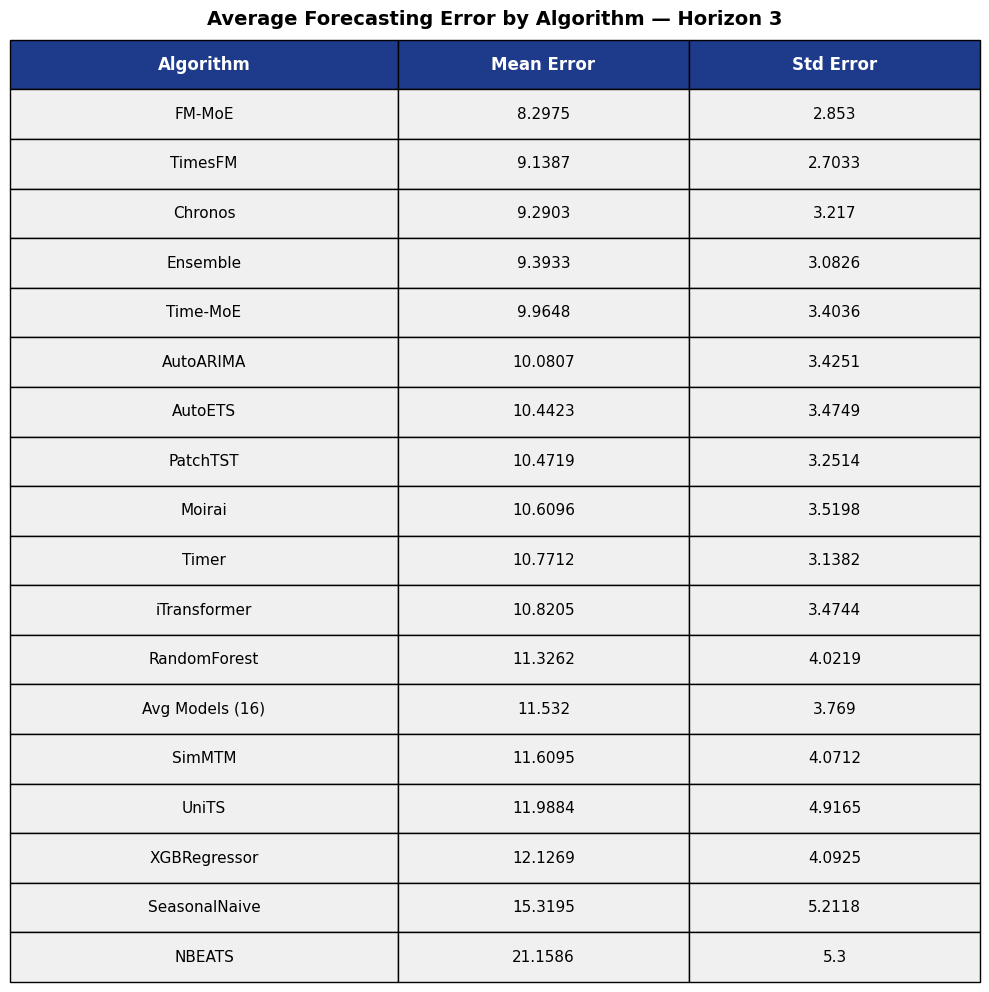

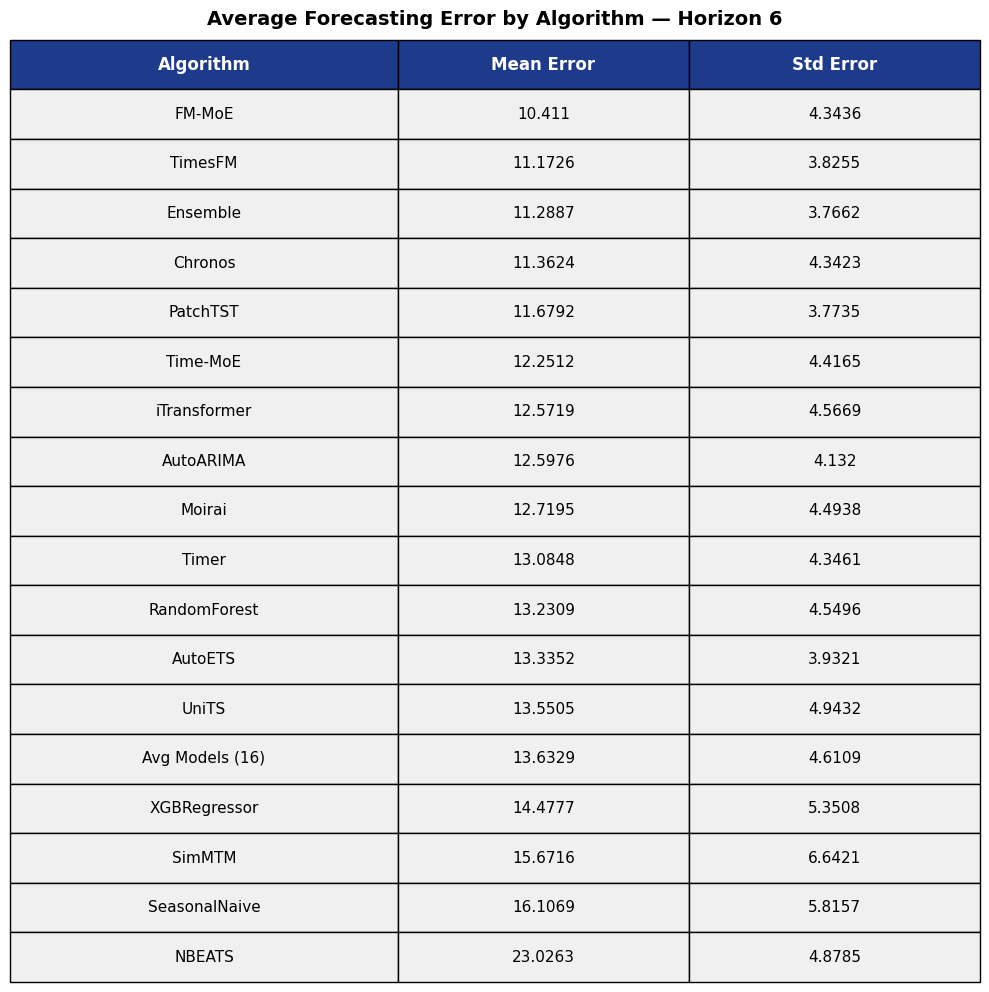

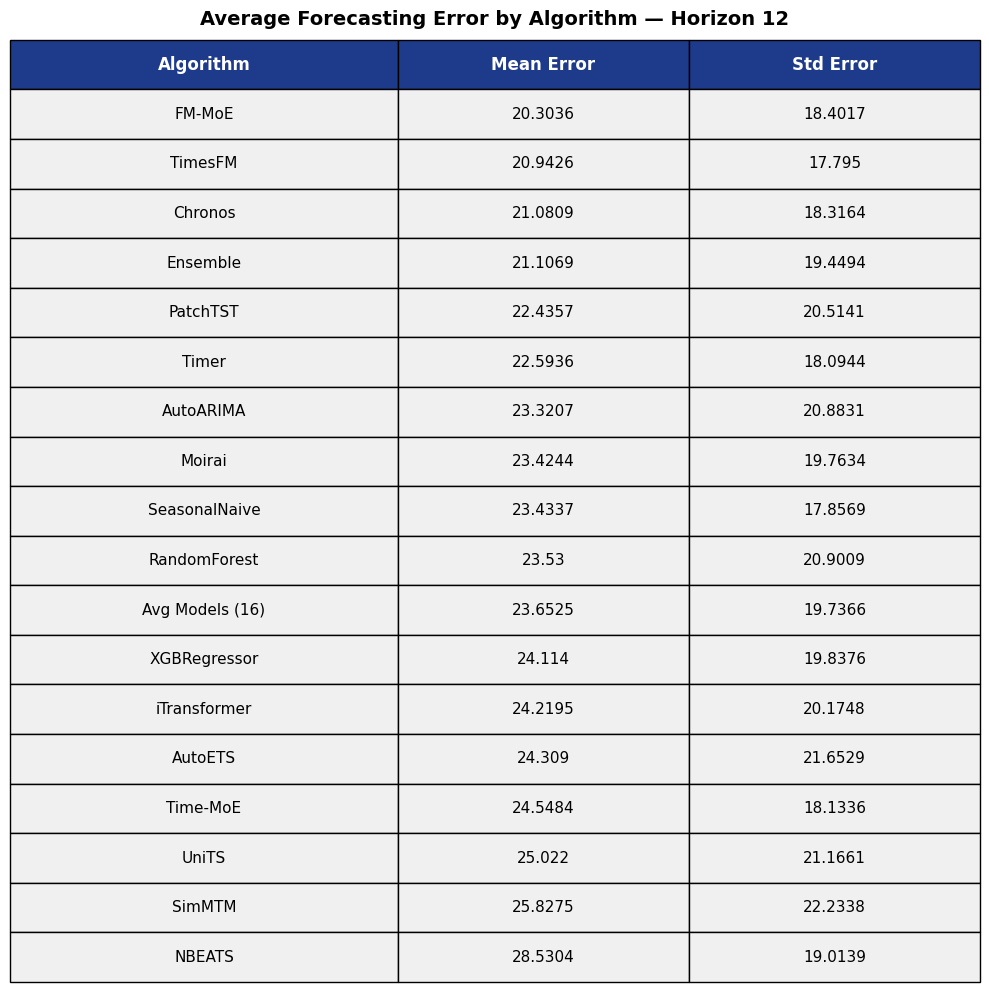

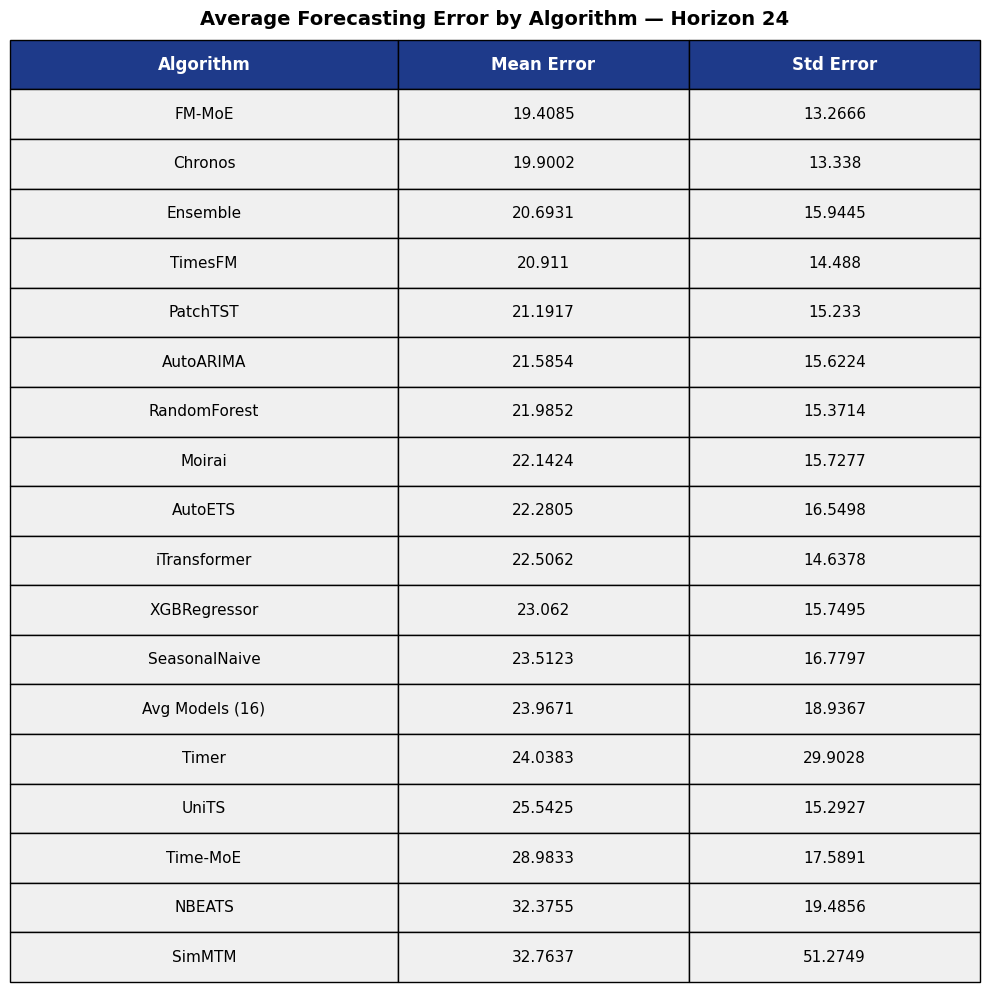


Tables successfully generated.

Summary:
- Total records: 9180
- Unique algorithms: 17
- Horizons: horizon_3, horizon_6, horizon_12, horizon_24


In [2]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# CONFIGURATION
# ==========================================================
BASE_RESULTS_PATH = "RESULTADOS_COMPLETOS_ANP/results_by_state_year"

# Resultados dos modelos adicionais (UniTS, SimMTM).
NEW_MODELS_PATH = "results_anp_novos_modelos/novos_models"
NEW_MODELS_LABEL = "novos_models"

TARGET_PRODUCTS = [
    "Etanolhidratado",
    "Gasolinac",
    "Glp",
    "Oleodiesel",
    "Querosenedeaviacao"
]

BEST_EXPERIMENTS = {

    "horizon_3":  "model_topk_2_norm_std_noise_True_ep_30_lr_0.001",
    "horizon_6":  "model_topk_2_norm_std_noise_True_ep_30_lr_0.001",
    "horizon_12": "model_topk_2_norm_std_noise_True_ep_100_lr_0.001",
    "horizon_24": "model_topk_2_norm_std_noise_True_ep_100_lr_0.001"
}

HORIZON_ORDER = ["horizon_3", "horizon_6", "horizon_12", "horizon_24"]

REFERENCE_MODEL = "FM-MoE"


# ==========================================================
# LEITURA DE UMA PASTA horizon_*
# (erro médio de cada modelo sobre os derivados alvo)
# ==========================================================
def read_mean_error_rows(horizon_path, horizon, exp_name):

    rows = []

    for file in sorted(os.listdir(horizon_path)):

        if not file.endswith(".csv"):
            continue

        # identificador da instância: results_<estado>_<ano>
        year = os.path.splitext(file)[0]
        file_path = os.path.join(horizon_path, file)

        df = pd.read_csv(file_path)

        metric_cols = [c for c in TARGET_PRODUCTS if c in df.columns]

        if len(metric_cols) == 0:
            print(f"[WARNING] No valid columns in {file_path}")
            continue

        df["mean_error"] = df[metric_cols].mean(axis=1)

        for _, row in df.iterrows():

            rows.append({
                "Algorithm": row["Modelo"],
                "Horizon": horizon,
                "Year": year,
                "Error": row["mean_error"],
                "Experiment": exp_name
            })

    return rows


# ==========================================================
# LOAD RESULTS
# ==========================================================
rows_all = []

for horizon, exp_name in BEST_EXPERIMENTS.items():

    # 1) modelos originais (melhor experimento daquele horizonte)
    exp_horizon_path = os.path.join(BASE_RESULTS_PATH, exp_name, horizon)

    if os.path.isdir(exp_horizon_path):
        rows_all.extend(read_mean_error_rows(exp_horizon_path, horizon, exp_name))
    else:
        print(f"[WARNING] Experiment not found: {exp_horizon_path}")

    # 2) modelos novos (UniTS, SimMTM) — mesma grade de estado x ano
    new_horizon_path = os.path.join(NEW_MODELS_PATH, horizon)

    if os.path.isdir(new_horizon_path):
        rows_all.extend(read_mean_error_rows(new_horizon_path, horizon, NEW_MODELS_LABEL))
    else:
        print(f"[WARNING] New models not found: {new_horizon_path}")


# ==========================================================
# BUILD DATAFRAME
# ==========================================================
df_all = pd.DataFrame(rows_all)

if len(df_all) == 0:

    print("\n[ERROR] No data loaded. Check experiment paths.")

else:

    df_all = (
        df_all
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["Error"])
    )

    new_models = sorted(
        df_all.loc[df_all["Experiment"] == NEW_MODELS_LABEL, "Algorithm"].unique()
    )

    print(f"\n[INFO] Total records loaded: {len(df_all)}")
    print(f"[INFO] Experiments processed: {df_all['Experiment'].nunique()}")
    print(f"[INFO] Horizons: {sorted(df_all['Horizon'].unique())}")
    print(f"[INFO] Algorithms ({df_all['Algorithm'].nunique()}): "
          f"{sorted(df_all['Algorithm'].unique())}")
    print(f"[INFO] New models included: {new_models}")

    # cada (Horizonte, Estado/Ano) precisa ter todos os algoritmos
    counts_per_instance = (
        df_all
        .groupby(["Horizon", "Year"])["Algorithm"]
        .nunique()
    )

    n_algorithms = df_all["Algorithm"].nunique()

    if (counts_per_instance != n_algorithms).any():
        print(f"\n[WARNING] Existem instâncias sem os {n_algorithms} algoritmos; "
              f"as médias por modelo usam quantidades diferentes de amostras.")
    else:
        print(f"[OK] Todas as {len(counts_per_instance)} instâncias "
              f"(horizonte x estado x ano) têm os {n_algorithms} algoritmos.")


    # ======================================================
    # SUMMARY TABLE
    # ======================================================
    df_summary = (
        df_all
        .groupby(["Algorithm", "Horizon"])
        .agg(
            Mean_Error=("Error", "mean"),
            Std_Error=("Error", "std")
        )
        .reset_index()
    )

    df_summary = df_summary.sort_values(["Horizon", "Mean_Error"])

    df_summary["Mean_Error"] = df_summary["Mean_Error"].round(4)
    df_summary["Std_Error"] = df_summary["Std_Error"].round(4)

    # Rename columns for paper formatting
    df_summary = df_summary.rename(columns={
        "Mean_Error": "Mean Error",
        "Std_Error": "Std Error"
    })


    # ======================================================
    # TABLE VISUALIZATION
    # ======================================================
    present = set(df_summary["Horizon"].unique())

    horizons = ([h for h in HORIZON_ORDER if h in present]
                + sorted(present - set(HORIZON_ORDER)))

    for horizon in horizons:

        df_h = df_summary[df_summary["Horizon"] == horizon].copy()

        # Linha de média dos modelos exceto o FM-MoE
        # (inclui agora UniTS e SimMTM)
        df_others = df_h[df_h["Algorithm"] != REFERENCE_MODEL]
        others_mean = round(df_others["Mean Error"].mean(), 4)
        others_std  = round(df_others["Std Error"].mean(), 4)

        avg_row = pd.DataFrame([{
            "Algorithm": f"Avg Models ({len(df_others)})",
            "Mean Error": others_mean,
            "Std Error":  others_std
        }])

        df_display = pd.concat(
            [df_h[["Algorithm", "Mean Error", "Std Error"]], avg_row],
            ignore_index=True
        )

        # Ordena por Mean Error
        df_display = df_display.sort_values("Mean Error").reset_index(drop=True)

        fig, ax = plt.subplots(figsize=(10, len(df_display) * 0.5 + 1))

        ax.axis("off")
        ax.axis("tight")

        colors = [["#F0F0F0"] * 3 for _ in df_display["Algorithm"]]

        table = ax.table(
            cellText=df_display.values,
            colLabels=df_display.columns,
            cellLoc="center",
            loc="center",
            colWidths=[0.4, 0.3, 0.3],
            cellColours=colors
        )

        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2.5)

        # Header style
        for i in range(len(df_display.columns)):
            cell = table[(0, i)]
            cell.set_facecolor("#1E3A8A")
            cell.set_text_props(weight="bold", color="white", fontsize=12)

        horizon_number = horizon.split("_")[-1]

        plt.title(
            f"Average Forecasting Error by Algorithm — Horizon {horizon_number}",
            fontsize=14,
            fontweight="bold",
            pad=20
        )

        plt.tight_layout()
        plt.show()


    print("\nTables successfully generated.")
    print("\nSummary:")
    print(f"- Total records: {len(df_all)}")
    print(f"- Unique algorithms: {df_all['Algorithm'].nunique()}")
    print(f"- Horizons: {', '.join(horizons)}")
